# ガウス混合モデルにおける推論

## 準備

In [2]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 利用可能なフォント一覧を取得
available_fonts = [f.name for f in fm.fontManager.ttflist]
print("利用可能なフォント一覧:")
print(available_fonts)

# 優先フォント設定
font_families = []

if "Yu Gothic" in available_fonts:
    font_families.append("Yu Gothic")  # Windows向け日本語
    print("日本語フォント: Yu Gothic を使用します")
elif "Noto Sans CJK JP" in available_fonts:
    font_families.append("Noto Sans CJK JP")  # Linux向け日本語
    print("日本語フォント: Noto Sans CJK JP を使用します")
else:
    print("日本語フォントが見つかりません．")
    print("結果画像内の日本語が豆腐になる可能性があります")

# 欧文用フォントを追加（必ずカバーしておきたい）
font_families.append("DejaVu Sans")

# matplotlib に適用
plt.rcParams["font.family"] = font_families
print("最終的に使用するフォント順:", plt.rcParams["font.family"])


利用可能なフォント一覧:
['STIXSizeThreeSym', 'DejaVu Sans Mono', 'cmsy10', 'DejaVu Serif', 'cmss10', 'DejaVu Serif', 'cmex10', 'cmr10', 'DejaVu Sans', 'STIXSizeThreeSym', 'DejaVu Serif', 'DejaVu Sans', 'cmmi10', 'STIXGeneral', 'cmtt10', 'STIXNonUnicode', 'DejaVu Sans', 'STIXSizeTwoSym', 'DejaVu Sans', 'STIXGeneral', 'STIXSizeOneSym', 'DejaVu Sans Mono', 'STIXSizeFourSym', 'STIXNonUnicode', 'STIXNonUnicode', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Sans Mono', 'STIXSizeFourSym', 'STIXGeneral', 'STIXSizeFiveSym', 'STIXSizeTwoSym', 'DejaVu Serif Display', 'cmb10', 'STIXNonUnicode', 'STIXGeneral', 'STIXSizeOneSym', 'Ubuntu', 'Ubuntu', 'Ubuntu Sans', 'Ubuntu Sans', 'Ubuntu', 'DejaVu Serif', 'Ubuntu Mono', 'Ubuntu', 'Ubuntu Mono', 'Ubuntu', 'Noto Sans CJK JP', 'DejaVu Sans', 'Ubuntu', 'Ubuntu Mono', 'Ubuntu Mono', 'DejaVu Sans Mono', 'Ubuntu', 'Ubuntu Sans Mono', 'Noto Serif CJK JP', 'DejaVu Sans Mono', 'Noto Sans CJK JP', 'Ubuntu', 'Noto Serif CJK JP', 'Ubuntu Mono', 'DejaVu 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def plot_ellipse(ax, mean, cov, color, label, sigma_scale=2):
    """
    指定された平均と共分散を持つガウス分布の信頼区間楕円を描画する関数

    Args:
        ax (matplotlib.axes.Axes): 描画対象のAxesオブジェクト
        mean (np.ndarray): 分布の平均 (2次元)
        cov (np.ndarray): 分布の共分散行列 (2x2)
        color (str): 楕円の色
        label (str): 凡例のラベル
        sigma_scale (int): 何シグマ区間を描画するか (例: 2 for 2σ)
    """
    # 共分散行列の固有値と固有ベクトルを計算
    # 固有値が楕円の軸の長さの2乗、固有ベクトルが楕円の軸の方向に対応する
    eigvals, eigvecs = np.linalg.eigh(cov)

    # 固有ベクトルの最初のベクトルから角度を計算
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    # 固有値から楕円の幅と高さを計算
    # 固有値は分散なので、平方根を取って標準偏差にする
    width, height = 2 * sigma_scale * np.sqrt(eigvals)

    # 楕円のパッチを作成
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=color,
        fc="None",
        lw=2,
        label=label,
    )

    # Axesにパッチを追加
    ax.add_patch(ellipse)

## シナリオ設定

機械学習のアルゴリズムを試す際によく使われる、アヤメの品種分類問題のように、データがいくつかの明確なグループ（クラスタ）に分かれている状況を想定します。

  * **クラスタ数 (K)**: 3
  * **データ数 (N)**: 500
  * **次元数 (D)**: 2
  * **真の混合比率 ($\boldsymbol{\pi}$)**: 3つのクラスタから、それぞれ 50%, 30%, 20% の割合でデータが生成されるとします。
      * $\boldsymbol{\pi} = [0.5, 0.3, 0.2]$
  * **真の平均 ($\boldsymbol{\mu}$)**: 3つのクラスタが2次元平面上で離れた位置に中心を持つように設定します。
      * $\boldsymbol{\mu}_1 = [0, 5]$
      * $\boldsymbol{\mu}_2 = [-5, -5]$
      * $\boldsymbol{\mu}_3 = [5, -5]$
  * **真の共分散行列 ($\boldsymbol{\Sigma}$)**: 各クラスタが異なる形状と向きを持つように、共分散行列を設定します。これにより、より現実的で面白い問題設定になります。（ギブスサンプリングでは精度行列 $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$ を用いますが、データ生成時は共分散行列の方が直感的です。）
      * **クラスタ1**: 標準的な円形の分布
        $\boldsymbol{\Sigma}_1 = \begin{pmatrix} 3 & 0 \\ 0 & 3 \end{pmatrix}$
      * **クラスタ2**: 斜めに長く伸びた楕円形の分布
        $\boldsymbol{\Sigma}_2 = \begin{pmatrix} 4 & 2.5 \\ 2.5 & 2 \end{pmatrix}$
      * **クラスタ3**: 横に広い楕円形の分布
        $\boldsymbol{\Sigma}_3 = \begin{pmatrix} 5 & -2 \\ -2 & 2 \end{pmatrix}$

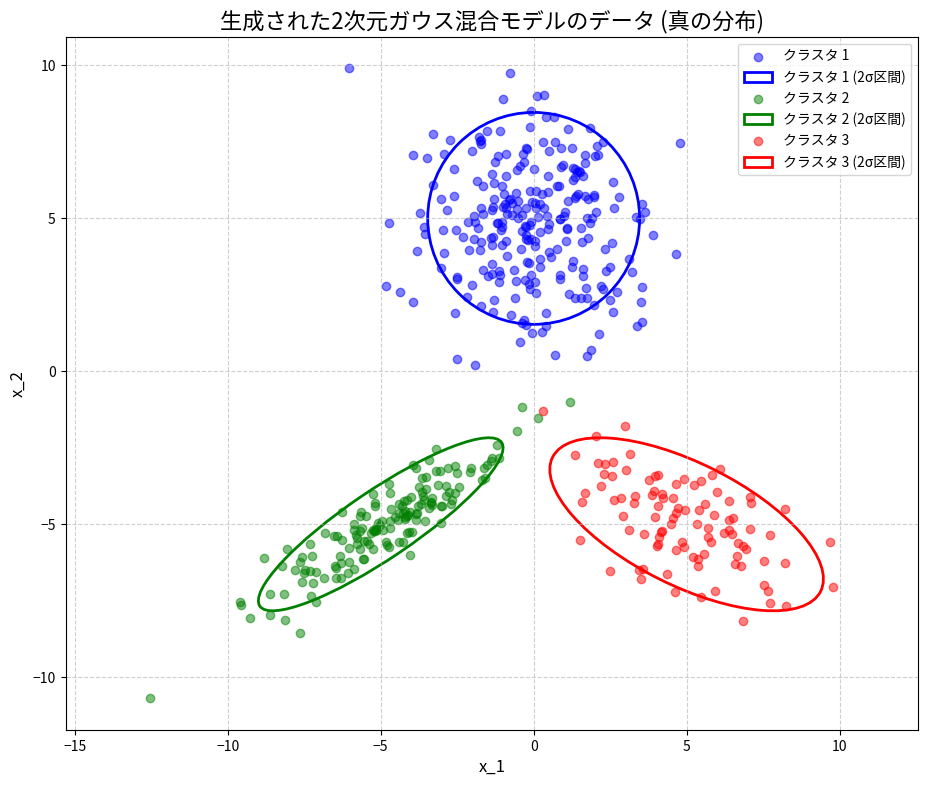

In [4]:
# 1. シナリオ設定
# --------------------------------------------------
# 真のパラメータ
K = 3  # クラスタ数
N = 500  # データ数
D = 2  # 次元数

# 混合比率
true_pi = np.array([0.5, 0.3, 0.2])

# 平均
true_mu = np.array([[0.0, 5.0], [-5.0, -5.0], [5.0, -5.0]])

# 共分散行列
true_sigma = np.array(
    [
        [
            [3.0, 0.0],
            [0.0, 3.0],
        ],
        [
            [4.0, 2.5],
            [2.5, 2.0],
        ],
        [
            [5.0, -2.0],
            [-2.0, 2.0],
        ],
    ]
)


# 2. データの生成
# --------------------------------------------------
# 潜在変数 S (各データがどのクラスタに属するか) を生成
true_s = np.random.choice(np.arange(K), p=true_pi, size=N)

# 観測データ X を格納する配列
X = np.zeros((N, D))

# 各データを対応するガウス分布からサンプリング
for n in range(N):
    k = true_s[n]  # データnが属するクラスタ
    X[n] = np.random.multivariate_normal(mean=true_mu[k], cov=true_sigma[k])


# 3. データの可視化
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 9))

colors = ["blue", "green", "red"]
scatter_labels = ["クラスタ 1", "クラスタ 2", "クラスタ 3"]
ellipse_labels = ["クラスタ 1 (2σ区間)", "クラスタ 2 (2σ区間)", "クラスタ 3 (2σ区間)"]


for k in range(K):
    # k番目のクラスタに属するデータだけを抽出
    cluster_data = X[true_s == k]
    # 散布図をプロット
    ax.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        color=colors[k],
        alpha=0.5,
        label=scatter_labels[k],
    )
    # 2シグマ区間の楕円をプロット
    plot_ellipse(ax, true_mu[k], true_sigma[k], colors[k], ellipse_labels[k])


ax.set_title("生成された2次元ガウス混合モデルのデータ (真の分布)", fontsize=16)
ax.set_xlabel("x_1", fontsize=12)
ax.set_ylabel("x_2", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.axis("equal")  # 軸のスケールを揃える
plt.show()


## 対数尤度の計算

### 多変量ガウス密度

観測ベクトル $x_n \in \mathbb{R}^D$ に対するクラスタ $k$ の多変量ガウス密度は

$$
\mathcal{N}(x_n \mid \mu_k, \Sigma_k)
= \frac{1}{(2\pi)^{D/2}|\Sigma_k|^{1/2}}
\exp\left(-\tfrac{1}{2}(x_n-\mu_k)^\top \Sigma_k^{-1}(x_n-\mu_k)\right).
$$


### 1点の尤度（混合）

混合係数を $\pi_k$（$\sum_{k=1}^K\pi_k=1,\ \pi_k\ge0$）とすると、データ点 $x_n$ の尤度は

$$
p(x_n \mid \pi, \mu, \Sigma)
= \sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k).
$$


### データ集合全体の尤度

独立同分布を仮定するとデータ集合 $X=\{x_1,\dots,x_N\}$ の尤度は

$$
L(\pi, \mu, \Sigma \mid X)
= \prod_{n=1}^{N} p(x_n \mid \pi, \mu, \Sigma)
= \prod_{n=1}^{N}\left(\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k)\right).
$$


### 対数尤度（最終式）

数値安定性のために対数を取ると

$$
\ell(\pi, \mu, \Sigma \mid X)
= \log L(\pi, \mu, \Sigma \mid X)
= \sum_{n=1}^{N} \log\!\left(\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k)\right).
$$


---

### 数値安定化（実装上の注意）

上の式をそのまま計算すると小さい値の掛け算でアンダーフローするので、**対数空間で計算して log-sum-exp を使う**のが普通です。すなわち各 $k$ について

$$
\log \big(\pi_k\,\mathcal{N}(x_n \mid \mu_k, \Sigma_k)\big)
= \log\pi_k + \log\mathcal{N}(x_n \mid \mu_k, \Sigma_k),
$$

を計算し、

$$
\log\Big(\sum_k \pi_k\,\mathcal{N}(\cdot)\Big)
= \operatorname{logsumexp}_k\big(\log\pi_k + \log\mathcal{N}(\cdot)\big).
$$

`logsumexp(a_k)` は数値的に安定な方法で $\log\sum_k e^{a_k}$ を返します。


In [5]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp


# --- 対数尤度を計算するヘルパー関数 (GMM版) ---
def calculate_log_likelihood_gmm(
    X: np.ndarray,  # 観測データ (N, D)
    pi: np.ndarray,  # 混合比率 (K,)
    mu: np.ndarray,  # 平均 (K, D)
    sigma: np.ndarray,  # 共分散行列 (K, D, D)
) -> float:
    """
    与えられたパラメータで、GMMの対数尤度を計算する。

    Log-Likelihood = Σ_n log( Σ_k pi_k * N(x_n | mu_k, sigma_k) )
    """
    N, D = X.shape
    K = len(pi)

    log_pi = np.log(pi + 1e-16)  # 0除算防止
    log_prob = np.zeros((N, K))

    # 各データnと各クラスタkの組み合わせに対して、重み付きの確率密度を計算
    for k in range(K):
        try:
            # log(π_k) + log N(x|μ_k,Σ_k)
            log_pdf = multivariate_normal.logpdf(X, mean=mu[k], cov=sigma[k]) # N個のデータをまとめて計算
            log_prob[:, k] = log_pi[k] + log_pdf
        except np.linalg.LinAlgError:
            # 正定値化して再計算
            sigma_reg = sigma[k] + 1e-6 * np.eye(D)
            log_pdf = multivariate_normal.logpdf(X, mean=mu[k], cov=sigma_reg)
            log_prob[:, k] = log_pi[k] + log_pdf

    # log-sum-exp で数値安定化
    log_likelihood = np.sum(logsumexp(log_prob, axis=1))
    return float(log_likelihood)


## ギブスサンプリング

In [ ]:
import time
from scipy.stats import dirichlet, wishart, multivariate_normal

# D: データ次元(今回は2次元)

# --- 1. ハイパーパラメータの設定 ---
# ディリクレ分布のハイパーパラメータ
alpha_0 = np.ones(K)
# ガウス-ウィシャート分布のハイパーパラメータ
m_0 = np.zeros(D)
beta_0 = 1.0
nu_0 = D  # 自由度は最小のD
W_0 = np.eye(D)
W_0_inv = np.linalg.inv(W_0)

# --- 2. パラメータと潜在変数の初期化 ---
# πの初期化
pi = dirichlet.rvs(alpha=alpha_0).flatten()

# Λ (精度行列) の初期化
Lambda = np.array([wishart.rvs(df=nu_0, scale=W_0) for _ in range(K)])

# μ の初期化
mu = np.array(
    [
        multivariate_normal.rvs(mean=m_0, cov=np.linalg.inv(beta_0 * Lambda[k]))
        for k in range(K)
    ]
)

# S の初期化 (ランダムに割り当て)
s_nk = np.random.multinomial(
    1,
    pvals=[1 / K] * K,  # = [1/K, 1/K, 1/K]: 均等に割り当て
    size=N,
)

# --- 3. ギブスサンプリングの実行 ---
num_iterations = 30

# --- 履歴保存用の配列 ---
pi_samples = []
mu_samples = []
sigma_samples = []  # 精度Λではなく共分散Σを保存
log_likelihood_history = []

print("Gibbs sampling for GMM started...")
start_time = time.time()

for i in range(num_iterations):
    # --- (1) 潜在変数 S のサンプリング 式(4.93),(4.94) ---
    log_eta = np.zeros((N, K))  # (N,K)の行列
    for k in range(K):
        # 対数尤度項の計算

        # (x-μ)T Λ (x-μ) の計算
        diff = X - mu[k]  # (x-μ)T : 全データN個について処理して(N,D)
        # Lambda[k] は(D,D)
        # (diff @ Lambda[k]) は(N,D), diffは(N,D) -> 要素ごとの積をとってsum
        #   -> (N, 1)で縦にマハラノビス距離(x_n-μ)T Λ (x_n-μ)が並ぶ
        log_likelihood_term = np.sum((diff @ Lambda[k]) * diff, axis=1)

        # log(η_nk) の比例項
        log_eta[:, k] = (  # 縦ベクトル(N,1)でK列を順に埋めていくイメージ
            -0.5 * log_likelihood_term
            + 0.5 * np.log(np.linalg.det(Lambda[k]) + 1e-10)
            + np.log(pi[k] + 1e-10)
        )

    # Log-Sum-Expトリックで正規化
    log_eta_normalized = log_eta - logsumexp(
        log_eta, axis=1, keepdims=True
    )  # k軸方向に和をとって正規化
    eta = np.exp(log_eta_normalized)

    # カテゴリ分布からSをサンプリング
    for n in range(N):
        s_nk[n] = np.random.multinomial(1, pvals=eta[n])

    # --- (2) パラメータ (μ, Λ) のサンプリング ---
    # 十分統計量の計算
    # ∑_n s_nk (各クラスタに割り当てられたデータ数)
    N_k = s_nk.sum(axis=0)  # (K,)
    # ∑_n s_nk * x_n (各クラスタに割り当てられたデータの和)
    sum_x_k = s_nk.T @ X  # (K, D) = (K, 2)
    # ∑_n s_nk * x_n * x_n^T (各クラスタに割り当てられたデータの自己外積の和)
    sum_xxT_k = np.einsum("nk,ni,nj->kij", s_nk, X, X)  # (K, D, D)のテンソル

    for k in range(K):
        if (
            N_k[k] == 0
        ):  # データが割り当てられなかったクラスタは事前分布からサンプリング
            Lambda[k] = wishart.rvs(df=nu_0, scale=W_0)
            mu[k] = multivariate_normal.rvs(
                mean=m_0, cov=np.linalg.inv(beta_0 * Lambda[k])
            )
            continue

        # 事後分布のパラメータを計算
        # 式(4.99)
        hat_beta_k = N_k[k] + beta_0
        hat_m_k = (sum_x_k[k] + beta_0 * m_0) / hat_beta_k

        # 式(4.103)
        # W_k_hat^-1 の計算 (式 4.101, 4.103)
        hat_W_k_inv = (
            sum_xxT_k[k]
            + beta_0 * np.outer(m_0, m_0)
            - hat_beta_k * np.outer(hat_m_k, hat_m_k)
            + W_0_inv
        )
        hat_nu_k = N_k[k] + nu_0

        # サンプリング 式(4.102), (4.98)
        Lambda[k] = wishart.rvs(df=hat_nu_k, scale=np.linalg.inv(hat_W_k_inv))
        mu[k] = multivariate_normal.rvs(
            mean=hat_m_k, cov=np.linalg.inv(hat_beta_k * Lambda[k])
        )

    # --- (3) 混合比率 π のサンプリング 式(4.44),(4.45) ---
    hat_alpha = alpha_0 + N_k
    pi = dirichlet.rvs(alpha=hat_alpha).flatten()

    # --- サンプルと対数尤度を保存 ---
    # 共分散行列に変換して保存
    current_sigma = np.linalg.inv(Lambda)
    pi_samples.append(pi.copy())
    mu_samples.append(mu.copy())
    sigma_samples.append(current_sigma.copy())

    # 対数尤度を計算して保存
    log_likelihood = calculate_log_likelihood_gmm(X, pi, mu, current_sigma)
    log_likelihood_history.append(log_likelihood)

    if (i + 1) % 10 == 0:
        print(
            f"Iteration {i + 1}/{num_iterations} ... Log Likelihood: {log_likelihood:.2f}"
        )


end_time = time.time()
print("\nGibbs sampling finished.")
print(f"Total execution time: {end_time - start_time:.2f} seconds")

# --- 4. サンプルをNumpy配列に変換 ---
pi_samples = np.array(pi_samples)
mu_samples = np.array(mu_samples)
sigma_samples = np.array(sigma_samples)
log_likelihood_history = np.array(log_likelihood_history)

# --- 5. 推定されたパラメータ (事後期待値) ---
estimated_pi = pi_samples.mean(axis=0)
estimated_mu = mu_samples.mean(axis=0)
estimated_sigma = sigma_samples.mean(axis=0)

print("\n--- Estimated Parameters (Posterior Mean) ---")
print("π:\n", estimated_pi)
print("\nμ:\n", estimated_mu)
print("\nΣ:\n", estimated_sigma)


Gibbs sampling for GMM started...
Iteration 10/30 ... Log Likelihood: -2361.12
Iteration 20/30 ... Log Likelihood: -2367.61
Iteration 30/30 ... Log Likelihood: -2366.77

Gibbs sampling finished.
Total execution time: 0.11 seconds

--- Estimated Parameters (Posterior Mean) ---
π:
 [0.48334724 0.21209794 0.30455483]

μ:
 [[-0.06335457  4.80954112]
 [ 4.57123943 -4.53792016]
 [-4.80011733 -4.92944446]]

Σ:
 [[[ 3.34000532 -0.16481267]
  [-0.16481267  3.82753572]]

 [[ 4.98012169 -2.69705721]
  [-2.69705721  3.9582851 ]]

 [[ 4.70774888  3.10784599]
  [ 3.10784599  2.4714885 ]]]


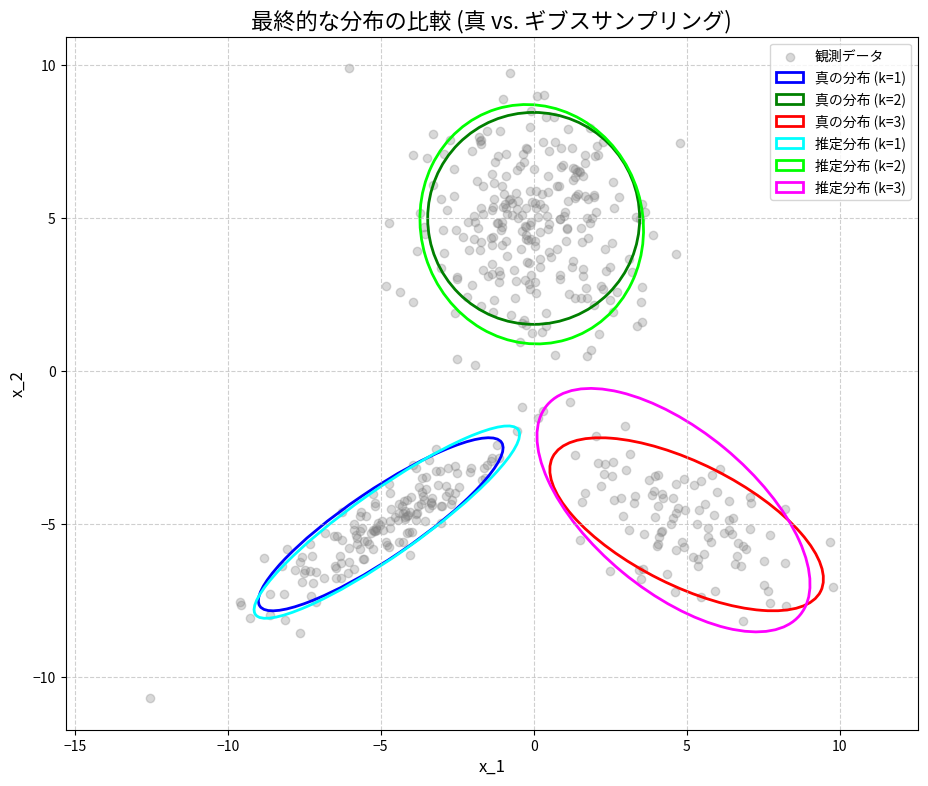

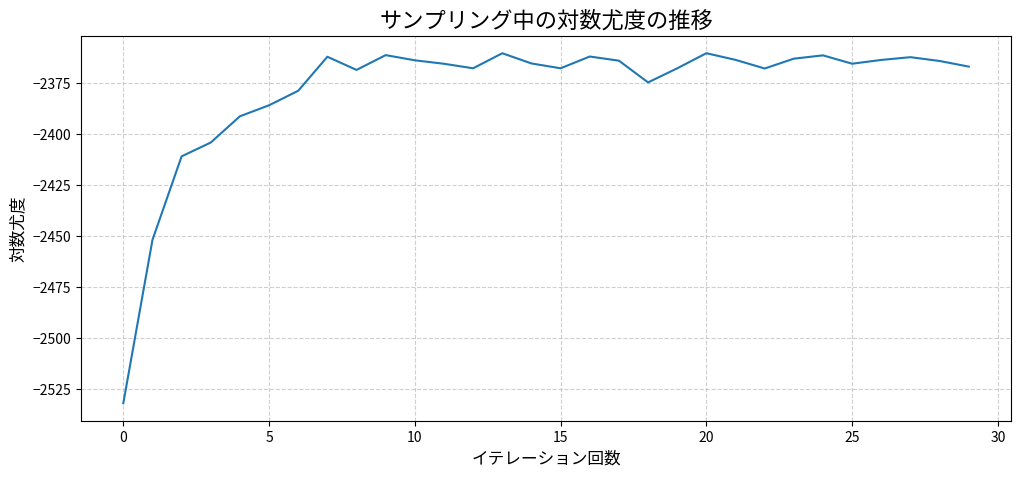

In [19]:
# --- 1. 静的なプロット ---

# (1-1) 最終的な推定結果と真の分布の比較
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 9))

# ラベルスイッチング対策：μのx座標を基準にクラスタのインデックスをソート
# これにより、真のクラスタと推定されたクラスタの色が対応するようになります
sort_indices_true = np.argsort(true_mu[:, 0])
sort_indices_est = np.argsort(estimated_mu[:, 0])

# 推定結果をソート
est_pi_sorted = estimated_pi[sort_indices_est]
est_mu_sorted = estimated_mu[sort_indices_est]
est_sigma_sorted = estimated_sigma[sort_indices_est]

# (A) 観測データをプロット (クラスタ情報は使わない)
ax.scatter(X[:, 0], X[:, 1], color="gray", alpha=0.3, label="観測データ")

# (B) 真の分布の2σ区間をプロット
true_colors = ["blue", "green", "red"]
for k_idx in range(K):
    original_k = sort_indices_true[k_idx]
    plot_ellipse(
        ax,
        true_mu[original_k],
        true_sigma[original_k],
        color=true_colors[k_idx],
        label=f"真の分布 (k={k_idx + 1})",
        sigma_scale=2,
    )

# (C) 推定された分布の2σ区間をプロット
est_colors = ["cyan", "lime", "magenta"]
for k_idx in range(K):
    plot_ellipse(
        ax,
        est_mu_sorted[k_idx],
        est_sigma_sorted[k_idx],
        color=est_colors[k_idx],
        label=f"推定分布 (k={k_idx + 1})",
        sigma_scale=2,
    )


ax.set_title("最終的な分布の比較 (真 vs. ギブスサンプリング)", fontsize=16)
ax.set_xlabel("x_1", fontsize=12)
ax.set_ylabel("x_2", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.axis("equal")
plt.show()


# (1-2) 対数尤度の推移
# --------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(log_likelihood_history)
plt.title("サンプリング中の対数尤度の推移", fontsize=16)
plt.xlabel("イテレーション回数", fontsize=12)
plt.ylabel("対数尤度", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# --- 2. アニメーションの作成 ---
print("\nGenerating animation...")

# アニメーション用の設定
num_samples = len(pi_samples)
# アニメーションが長くなりすぎないように、最大100フレームになるように間引く
animation_frames = np.linspace(0, num_samples - 1, min(100, num_samples), dtype=int)

fig_anim, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)


# アニメーションの更新関数
def update(frame_idx):
    # 現在のフレーム番号を取得
    i = animation_frames[frame_idx]

    # --- 左パネル: 分布の比較 ---
    ax1.clear()

    # 現在のフレームのサンプル値を取得
    current_pi = pi_samples[i]
    current_mu = mu_samples[i]
    current_sigma = sigma_samples[i]

    # ラベルスイッチング対策
    current_sort_indices = np.argsort(current_mu[:, 0])
    pi_sorted = current_pi[current_sort_indices]
    mu_sorted = current_mu[current_sort_indices]
    sigma_sorted = current_sigma[current_sort_indices]

    # 背景となるデータと真の分布は毎回描画
    ax1.scatter(X[:, 0], X[:, 1], color="gray", alpha=0.3)
    for k_idx in range(K):
        original_k = sort_indices_true[k_idx]
        plot_ellipse(
            ax1,
            true_mu[original_k],
            true_sigma[original_k],
            color=true_colors[k_idx],
            label=f"真 (k={k_idx + 1})",
        )

    # 現在の推定分布をプロット
    for k_idx in range(K):
        plot_ellipse(
            ax1,
            mu_sorted[k_idx],
            sigma_sorted[k_idx],
            color=est_colors[k_idx],
            label=f"推定 (k={k_idx + 1})",
        )

    ax1.set_title(f"分布の推定 (イテレーション #{i + 1})")
    ax1.set_xlabel("x_1")
    ax1.set_ylabel("x_2")
    ax1.axis("equal")
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend()
    # 描画範囲を固定
    ax1.set_xlim(X[:, 0].min() - 2, X[:, 0].max() + 2)
    ax1.set_ylim(X[:, 1].min() - 2, X[:, 1].max() + 2)

    # --- 右パネル: 対数尤度の推移 ---
    ax2.clear()
    ax2.plot(log_likelihood_history, label="対数尤度")
    # 現在のフレーム位置にマーカー（点）をプロット
    ax2.plot(i, log_likelihood_history[i], "o", markersize=10, color="red")

    ax2.set_title("対数尤度の推移")
    ax2.set_xlabel("イテレーション")
    ax2.set_ylabel("対数尤度")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend()

    # y軸の範囲を少し広めに固定
    min_ll = log_likelihood_history.min()
    max_ll = log_likelihood_history.max()
    margin = (max_ll - min_ll) * 0.1
    ax2.set_ylim(min_ll - margin, max_ll + margin)

    return fig_anim.get_children()


# FuncAnimationを使ってアニメーションを作成
ani = FuncAnimation(
    fig_anim, update, frames=len(animation_frames), interval=150, blit=False
)
plt.close()  # 静的なプロットが表示されるのを防ぐ

# Jupyter Notebookにアニメーションを埋め込んで表示
display(HTML(ani.to_jshtml()))


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



Generating animation...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

In [20]:
# 動画の保存
ani.save("mixture_gaussian_gibbs_sampling_animation.gif", writer="pillow", fps=10)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

## 変分推論